# Задание 1
Исходный сигнал представляет собой синусоиду $f(x) = A_0sin(\omega_0x + \varphi_0)$
- Подготовить данные (набор координат $x, y$). Построить график исходного сигнала.

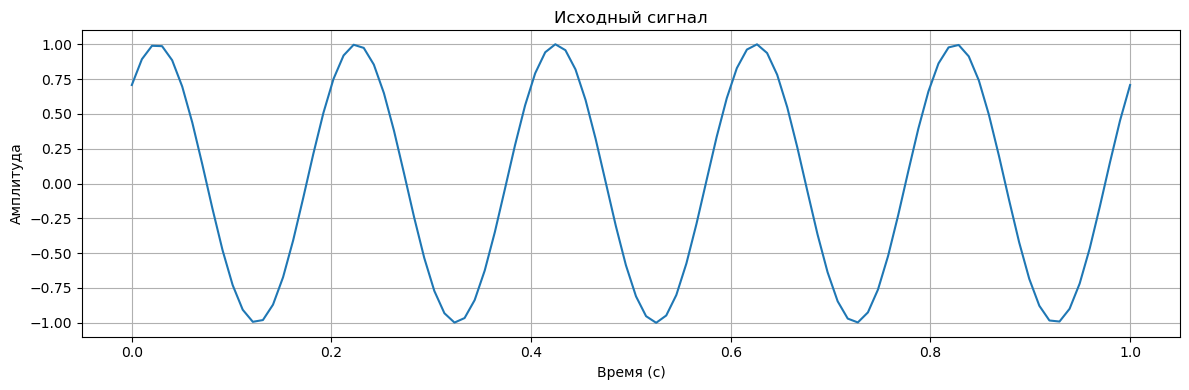

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# параметры сигнала
A0 = 1.0                     # амплитуда
f0 = 2.0                     # частота (Гц)
omega0 = 5.0 * np.pi * f0    # угловая частота
phi0 = np.pi / 4             # начальная фаза (45 градусов)
duration = 1.0               # длительность (с)
sampling_rate = 100.0        # частота дискретизации (Гц)

# генерация сигнала
num_samples = int(sampling_rate * duration)
x = np.linspace(0, duration, num_samples)
y = A0 * np.sin(omega0 * x + phi0)

plt.figure(figsize=(12, 4))
plt.plot(x, y)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title("Исходный сигнал")
plt.grid(True)
plt.tight_layout()

- Осуществить прямое преобразование Фурье (не используя библиотеки). Построить график.
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} k n}, \quad k = 0, 1, \dots, N-1$$

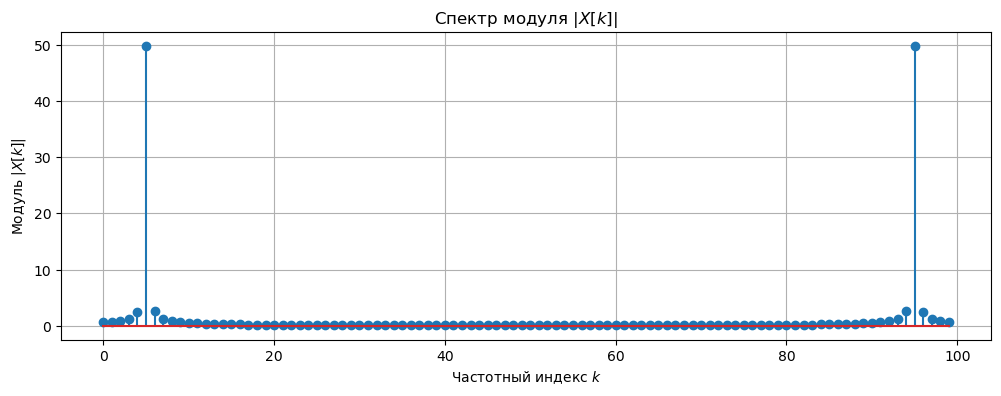

In [2]:
N = len(y)
y_dft = np.zeros(N, dtype=complex)
n = np.arange(N)

for k in range(N):
    y_dft[k] = np.sum(y * np.exp(-2j * np.pi * k * n / N))

plt.figure(figsize=(12, 4))
k_axis = np.arange(N)
plt.stem(k_axis, np.abs(y_dft))
plt.title('Спектр модуля $|X[k]|$')
plt.xlabel('Частотный индекс $k$')
plt.ylabel('Модуль $|X[k]|$')
plt.grid(True)

- Осуществить обратное преобразование Фурье. Построить график, который должен совпадать с исходным.
$$ x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \cdot e^{j \frac{2\pi}{N} k n}, \quad n = 0, 1, \dots, N-1 $$

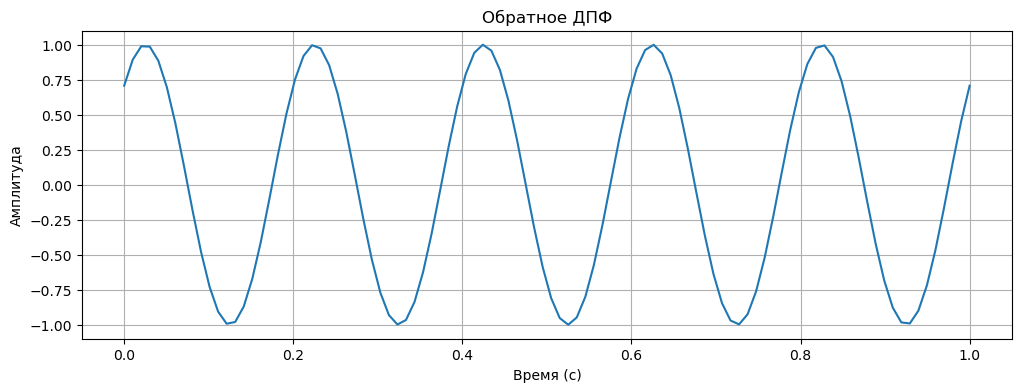

In [4]:
N = len(y_dft)
y_idft = np.zeros(N, dtype=complex)
k = np.arange(N)

for n in range(N):
    y_idft[n] = (1 / N) * np.sum(y_dft * np.exp(2j * np.pi * k * n / N))

plt.figure(figsize=(12, 4))
plt.plot(x, y_idft.real)
plt.title('Обратное ДПФ')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

- Реализовать то же с помощью библиотек и сравнить результаты.